# Proof-of-concept notebook
## Molecular and systems dissection of seed-stage and reproductive-stage resilience in rice under combined heat, drought, salinity, and oxidative stress

This notebook builds a **literature-benchmarked simulation framework** for rice resilience under single and combined abiotic stress. It is designed as a **proof of concept**, not as a substitute for real phenotyping or omics experiments.

### What this notebook does
- Simulates a multi-genotype rice panel across seed and reproductive stages.
- Benchmarks simulated effect directions and approximate magnitudes against **peer-reviewed literature indexed in PubMed and AGRIS**, with additional agricultural indexing context from **AGRICOLA/NAL** where relevant.
- Generates both **plant-level** and **molecular-level** features.
- Performs comprehensive analyses, including stress-response profiling, PCA, clustering, hypothesis testing, and machine learning / AI prediction.
- Saves publication-style figures and tables.

### Important note on benchmarking
The simulated values are **anchored to broad ranges and effect directions reported in the literature**, including:
- reduced germination, root growth, pollen viability, spikelet fertility, and yield under salinity, drought, heat, and combined stress,
- increased ROS, H$_2$O$_2$, malondialdehyde, proline, Na$^+$/K$^+$ ratio, and antioxidant enzyme activity under stress,
- stronger injury under **combined** stress than under most single stresses.

These are used to create a biologically plausible synthetic dataset. They are **not pooled meta-analytic estimates**.

### Representative benchmark literature used to guide simulation assumptions
- Hasanuzzaman, M., Raihan, M. R. H., Masud, A. A. C., Rahman, K., Nowroz, F., Rahman, M., Nahar, K., & Fujita, M. (2021). Regulation of reactive oxygen species and antioxidant defense in plants under salinity. International Journal of Molecular Sciences, 22(17), 9326. https://www.mdpi.com/1422-0067/22/17/9326  ￼
- Sarma, B., Kashtoh, H., Tamang, T. L., Saha, A., Chandel, G., & Bhat, J. A. (2023). Abiotic stress in rice: Visiting the physiological response and its tolerance mechanisms. Plants, 12(23), 3948. https://www.mdpi.com/2223-7747/12/23/3948  ￼
- Xu, S., Lou, T., Zhao, N., Gao, Y., Dong, L., Jiang, H., & Shen, W. (2011). Enhancement of salinity tolerance during rice seed germination by presoaking with hemoglobin. International Journal of Molecular Sciences, 12(4), 2488–2501. https://www.mdpi.com/1422-0067/12/4/2488  ￼
- He, Y., Yang, B., He, Y., Zhan, C., Cheng, Y., Zhang, J., Wang, Z., & Diao, M. (2019). A quantitative trait locus, qSE3, promotes seed germination and seedling establishment under salinity stress in rice. The Plant Journal, 97(6), 1089–1104. https://onlinelibrary.wiley.com/doi/10.1111/tpj.14181  ￼
- Jagadish, S. V. K., Craufurd, P. Q., & Wheeler, T. R. (2007). High temperature stress and spikelet fertility in rice (Oryza sativa L.). Journal of Experimental Botany, 58(7), 1627–1635. https://academic.oup.com/jxb/article/58/7/1627/512931  ￼
- Hu, Q., Wang, W., Lu, Q. et al. (2021). Abnormal anther development leads to lower spikelet fertility in rice (Oryza sativa L.) under high temperature during the panicle initiation stage. BMC Plant Biol 21, 428. https://doi.org/10.1186/s12870-021-03209-w
- Da Costa, M. V. J., Ramegowda, V., Ramegowda, H. V., Senthil-Kumar, M., & Udayakumar, M. (2021). Targeted phytohormone profiling identifies potential regulators of spikelet fertility in rice under combined drought and heat stress. International Journal of Molecular Sciences, 22(21), 11690. https://www.mdpi.com/1422-0067/22/21/11690  ￼
- Mondal, K., Kar, R. K., & Chakraborty, A. (2024). Concurrent effect of drought and heat stress in rice (Oryza sativa L.): Physio-biochemical and molecular approach. 3 Biotech, 14, 132. https://link.springer.com/article/10.1007/s13205-024-03980-1  ￼
- Kumar, V., Srivastava, A. K., Sharma, D., Pandey, S. P., Pandey, M., Dudwadkar, A., Saha, J., Ranjan, A., & Suprasanna, P. (2024). Antioxidant defense and ionic homeostasis govern stage-specific response of salinity stress in contrasting rice varieties. Plants, 13(6), 778. https://www.mdpi.com/2223-7747/13/6/778  ￼

### Representative modeling assumptions derived from the literature
- Control germination in healthy lines is usually high, often around 85–98%.
- Salinity and drought reduce germination and root growth, while oxidative burden elevates H$_2$O$_2$ and MDA.
- Heat and combined drought + heat strongly reduce pollen viability and spikelet fertility.
- Stress often increases proline, SOD, CAT, and APX as defense responses, especially in more tolerant genotypes.
- Combined stress generally causes stronger losses than single stress.

In [1]:

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from sklearn.inspection import permutation_importance
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

np.random.seed(42)

OUTDIR = Path("rice_resilience_outputs")
FIGDIR = OUTDIR / "figures"
TABDIR = OUTDIR / "tables"
FIGDIR.mkdir(parents=True, exist_ok=True)
TABDIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.2,
    "font.size": 10
})

print("Output directory:", OUTDIR.resolve())


Output directory: /Users/petalc01/Resilient Seeds/rice_resilience_outputs


In [3]:

# Literature-guided benchmark ranges and stress multipliers.
# These are deliberately approximate and transparent, because the notebook is a proof of concept.

GENOTYPES = [f"G{idx:02d}" for idx in range(1, 41)]
subpop = (
    ["salt_tolerant"] * 8 +
    ["drought_tolerant"] * 8 +
    ["heat_tolerant"] * 8 +
    ["combined_tolerant"] * 8 +
    ["susceptible"] * 8
)
genotype_info = pd.DataFrame({"genotype": GENOTYPES, "subpopulation": subpop})

# latent resilience axes
def draw_trait_scores(subpop_name):
    if subpop_name == "salt_tolerant":
        return np.random.normal(0.4, 0.12), np.random.normal(0.0, 0.15), np.random.normal(0.0, 0.15), np.random.normal(0.2, 0.12)
    if subpop_name == "drought_tolerant":
        return np.random.normal(0.0, 0.15), np.random.normal(0.4, 0.12), np.random.normal(0.0, 0.15), np.random.normal(0.2, 0.12)
    if subpop_name == "heat_tolerant":
        return np.random.normal(0.0, 0.15), np.random.normal(0.0, 0.15), np.random.normal(0.4, 0.12), np.random.normal(0.2, 0.12)
    if subpop_name == "combined_tolerant":
        return np.random.normal(0.35, 0.10), np.random.normal(0.35, 0.10), np.random.normal(0.35, 0.10), np.random.normal(0.35, 0.10)
    return np.random.normal(-0.25, 0.10), np.random.normal(-0.25, 0.10), np.random.normal(-0.25, 0.10), np.random.normal(-0.15, 0.10)

scores = genotype_info["subpopulation"].apply(draw_trait_scores)
genotype_info[["salt_score", "drought_score", "heat_score", "redox_score"]] = pd.DataFrame(scores.tolist(), index=genotype_info.index)
genotype_info["general_resilience"] = genotype_info[["salt_score", "drought_score", "heat_score", "redox_score"]].mean(axis=1)

# treatment architecture
TREATMENTS = {
    "Control": {"heat": 0.0, "drought": 0.0, "salinity": 0.0, "oxidative": 0.0},
    "Heat": {"heat": 0.65, "drought": 0.0, "salinity": 0.0, "oxidative": 0.25},
    "Drought": {"heat": 0.0, "drought": 0.65, "salinity": 0.0, "oxidative": 0.30},
    "Salinity": {"heat": 0.0, "drought": 0.20, "salinity": 0.70, "oxidative": 0.40},
    "Oxidative": {"heat": 0.0, "drought": 0.0, "salinity": 0.0, "oxidative": 0.75},
    "Heat+Drought": {"heat": 0.75, "drought": 0.75, "salinity": 0.0, "oxidative": 0.55},
    "Heat+Salinity": {"heat": 0.65, "drought": 0.20, "salinity": 0.75, "oxidative": 0.60},
    "Drought+Salinity": {"heat": 0.10, "drought": 0.75, "salinity": 0.75, "oxidative": 0.60},
    "Combined_All": {"heat": 0.80, "drought": 0.80, "salinity": 0.80, "oxidative": 0.80},
}
STAGES = ["Seed", "Reproductive"]
REPS = [1, 2, 3]

benchmark_summary = pd.DataFrame({
    "feature_group": [
        "Seed germination", "Seed root growth", "Seed Na/K balance", "Seed ROS and MDA",
        "Seed proline and antioxidants", "Pollen viability", "Spikelet fertility",
        "Yield per plant", "Combined stress severity", "Tolerant genotype behavior"
    ],
    "literature_guided_direction": [
        "decrease under salinity, drought, combined stress",
        "decrease under salinity, drought, oxidative burden",
        "Na/K ratio increases under salinity",
        "H2O2 and MDA increase under stress",
        "proline, SOD, CAT, APX generally increase under stress",
        "decrease strongly under heat and heat+drought",
        "decrease strongly under heat and combined stress",
        "decrease under reproductive stress and compound stress",
        "stronger penalty than most single stresses",
        "lower injury markers, higher defense markers, better fertility/yield"
    ]
})
benchmark_summary


,feature_group,literature_guided_direction
0,Seed germination,"decrease under salinity, drought, combined stress"
1,Seed root growth,"decrease under salinity, drought, oxidative bu..."
2,Seed Na/K balance,Na/K ratio increases under salinity
3,Seed ROS and MDA,H2O2 and MDA increase under stress
4,Seed proline and antioxidants,"proline, SOD, CAT, APX generally increase unde..."
5,Pollen viability,decrease strongly under heat and heat+drought
6,Spikelet fertility,decrease strongly under heat and combined stress
7,Yield per plant,decrease under reproductive stress and compoun...
8,Combined stress severity,stronger penalty than most single stresses
9,Tolerant genotype behavior,"lower injury markers, higher defense markers, ..."


In [5]:

def bounded_normal(mean, sd, low, high, n=1):
    vals = np.random.normal(mean, sd, n)
    return np.clip(vals, low, high)

records = []

for _, g in genotype_info.iterrows():
    for treatment_name, sev in TREATMENTS.items():
        for stage in STAGES:
            for rep in REPS:
                salt = sev["salinity"]
                drought = sev["drought"]
                heat = sev["heat"]
                oxidative = sev["oxidative"]

                # genotype-specific effective stress load after resilience buffering
                buffered_salt = max(0, salt * (1 - 0.55 * g["salt_score"]))
                buffered_drought = max(0, drought * (1 - 0.55 * g["drought_score"]))
                buffered_heat = max(0, heat * (1 - 0.55 * g["heat_score"]))
                buffered_oxid = max(0, oxidative * (1 - 0.55 * g["redox_score"]))

                combined_bonus = 0.0
                nonzero = sum(v > 0 for v in [salt, drought, heat, oxidative])
                if nonzero >= 2:
                    combined_bonus = 0.08 * nonzero

                total_stress = buffered_salt + buffered_drought + buffered_heat + buffered_oxid + combined_bonus

                if stage == "Seed":
                    base_germ = 93 + 2.2 * g["general_resilience"]
                    base_root = 12.5 + 1.8 * g["general_resilience"]
                    base_vigor = 17 + 2.4 * g["general_resilience"]
                    base_nak = 0.42 - 0.10 * g["salt_score"]
                    base_h2o2 = 8.5 - 0.8 * g["redox_score"]
                    base_mda = 10.5 - 1.0 * g["redox_score"]
                    base_proline = 1.5 + 0.2 * g["drought_score"]
                    base_sod = 62 + 5 * g["redox_score"]
                    base_cat = 21 + 2.5 * g["redox_score"]
                    base_apx = 16 + 1.8 * g["redox_score"]
                    base_rwc = 88 + 1.0 * g["drought_score"]
                    base_chl = 2.2 + 0.08 * g["general_resilience"]

                    germination_pct = np.clip(base_germ - 14*buffered_salt - 10*buffered_drought - 7*buffered_heat - 8*buffered_oxid - 6*combined_bonus + np.random.normal(0, 2.2), 35, 99)
                    root_length_cm = np.clip(base_root - 2.6*buffered_salt - 2.3*buffered_drought - 1.0*buffered_heat - 1.8*buffered_oxid - 1.6*combined_bonus + np.random.normal(0, 0.8), 1.0, 18)
                    vigor_index = np.clip(base_vigor - 4.0*buffered_salt - 3.2*buffered_drought - 1.5*buffered_heat - 2.2*buffered_oxid - 2.2*combined_bonus + np.random.normal(0, 1.0), 2, 24)
                    na_k_ratio = np.clip(base_nak + 0.95*buffered_salt + 0.18*buffered_drought + 0.10*buffered_oxid + np.random.normal(0, 0.08), 0.1, 3.5)
                    h2o2 = np.clip(base_h2o2 + 6.0*buffered_salt + 5.0*buffered_drought + 4.2*buffered_heat + 6.8*buffered_oxid + 3.0*combined_bonus + np.random.normal(0, 1.1), 3, 35)
                    mda = np.clip(base_mda + 5.5*buffered_salt + 4.0*buffered_drought + 3.5*buffered_heat + 5.5*buffered_oxid + 2.5*combined_bonus + np.random.normal(0, 1.0), 4, 35)
                    proline = np.clip(base_proline + 1.9*buffered_salt + 2.4*buffered_drought + 1.0*buffered_heat + 1.2*buffered_oxid + 0.8*combined_bonus + np.random.normal(0, 0.25), 0.3, 8.0)
                    sod = np.clip(base_sod + 18*total_stress + 8*g["redox_score"] + np.random.normal(0, 4.0), 25, 135)
                    cat = np.clip(base_cat + 6.2*total_stress + 3.2*g["redox_score"] + np.random.normal(0, 1.5), 6, 50)
                    apx = np.clip(base_apx + 5.0*total_stress + 2.8*g["redox_score"] + np.random.normal(0, 1.2), 4, 40)
                    rwc = np.clip(base_rwc - 4.5*buffered_drought - 2.8*buffered_salt - 1.5*buffered_heat - 2.0*buffered_oxid - 1.5*combined_bonus + np.random.normal(0, 1.4), 55, 96)
                    chlorophyll = np.clip(base_chl - 0.28*buffered_salt - 0.22*buffered_drought - 0.12*buffered_heat - 0.18*buffered_oxid + np.random.normal(0, 0.08), 0.4, 3.0)

                    # molecular signals, arbitrary normalized expression units
                    OsHKT1_5 = np.clip(1.0 + 2.1*buffered_salt + 0.5*g["salt_score"] + np.random.normal(0, 0.2), 0.2, 5.5)
                    OsDREB2A = np.clip(1.0 + 1.7*buffered_drought + 0.7*combined_bonus + 0.4*g["drought_score"] + np.random.normal(0, 0.2), 0.2, 5.5)
                    OsHSP101 = np.clip(1.0 + 1.8*buffered_heat + 0.35*g["heat_score"] + np.random.normal(0, 0.2), 0.2, 5.5)
                    OsAPX2 = np.clip(1.0 + 2.0*buffered_oxid + 0.55*g["redox_score"] + np.random.normal(0, 0.2), 0.2, 5.5)
                    OsP5CS1 = np.clip(1.0 + 1.2*buffered_drought + 1.0*buffered_salt + 0.25*g["drought_score"] + np.random.normal(0, 0.15), 0.2, 5.5)

                    records.append({
                        "genotype": g["genotype"],
                        "subpopulation": g["subpopulation"],
                        "stage": stage,
                        "treatment": treatment_name,
                        "replicate": rep,
                        "general_resilience": g["general_resilience"],
                        "salt_score": g["salt_score"],
                        "drought_score": g["drought_score"],
                        "heat_score": g["heat_score"],
                        "redox_score": g["redox_score"],
                        "stress_load": total_stress,
                        "germination_pct": germination_pct,
                        "root_length_cm": root_length_cm,
                        "vigor_index": vigor_index,
                        "na_k_ratio": na_k_ratio,
                        "h2o2_umol_g": h2o2,
                        "mda_nmol_g": mda,
                        "proline_umol_g": proline,
                        "sod_u_g": sod,
                        "cat_u_g": cat,
                        "apx_u_g": apx,
                        "rwc_pct": rwc,
                        "chlorophyll_mg_g": chlorophyll,
                        "OsHKT1_5_expr": OsHKT1_5,
                        "OsDREB2A_expr": OsDREB2A,
                        "OsHSP101_expr": OsHSP101,
                        "OsAPX2_expr": OsAPX2,
                        "OsP5CS1_expr": OsP5CS1
                    })

                else:
                    base_pollen = 92 + 2.0 * g["general_resilience"]
                    base_spikelet = 88 + 2.0 * g["general_resilience"]
                    base_grain_weight = 28 + 1.2 * g["general_resilience"]
                    base_yield = 26 + 3.0 * g["general_resilience"]
                    base_photo = 24 + 1.5 * g["general_resilience"]
                    base_nak = 0.50 - 0.10 * g["salt_score"]
                    base_h2o2 = 9.0 - 0.7 * g["redox_score"]
                    base_mda = 11.0 - 0.9 * g["redox_score"]
                    base_proline = 1.8 + 0.25 * g["drought_score"]
                    base_sod = 64 + 6 * g["redox_score"]
                    base_cat = 22 + 2.5 * g["redox_score"]
                    base_apx = 17 + 2.0 * g["redox_score"]
                    base_rwc = 84 + 1.2 * g["drought_score"]

                    pollen_viability = np.clip(base_pollen - 20*buffered_heat - 13*buffered_drought - 9*buffered_salt - 8*buffered_oxid - 8*combined_bonus + np.random.normal(0, 2.5), 15, 99)
                    spikelet_fertility = np.clip(base_spikelet - 18*buffered_heat - 12*buffered_drought - 10*buffered_salt - 7*buffered_oxid - 9*combined_bonus + np.random.normal(0, 2.6), 10, 98)
                    grain_weight_mg = np.clip(base_grain_weight - 3.5*buffered_heat - 2.8*buffered_drought - 2.5*buffered_salt - 1.8*buffered_oxid - 1.5*combined_bonus + np.random.normal(0, 1.0), 12, 35)
                    yield_g_plant = np.clip(base_yield - 6.5*buffered_heat - 5.0*buffered_drought - 4.5*buffered_salt - 3.5*buffered_oxid - 3.5*combined_bonus + np.random.normal(0, 1.8), 4, 36)
                    photosynthesis = np.clip(base_photo - 3.0*buffered_heat - 4.0*buffered_drought - 2.2*buffered_salt - 2.0*buffered_oxid - 1.5*combined_bonus + np.random.normal(0, 1.0), 6, 32)
                    na_k_ratio = np.clip(base_nak + 0.90*buffered_salt + 0.14*buffered_drought + 0.10*buffered_oxid + np.random.normal(0, 0.08), 0.1, 3.5)
                    h2o2 = np.clip(base_h2o2 + 5.5*buffered_salt + 5.2*buffered_drought + 5.0*buffered_heat + 6.2*buffered_oxid + 2.8*combined_bonus + np.random.normal(0, 1.1), 3, 35)
                    mda = np.clip(base_mda + 5.0*buffered_salt + 4.5*buffered_drought + 4.8*buffered_heat + 5.0*buffered_oxid + 2.5*combined_bonus + np.random.normal(0, 1.0), 4, 35)
                    proline = np.clip(base_proline + 1.6*buffered_salt + 2.4*buffered_drought + 1.4*buffered_heat + 1.1*buffered_oxid + 0.9*combined_bonus + np.random.normal(0, 0.25), 0.3, 8.5)
                    sod = np.clip(base_sod + 17*total_stress + 8*g["redox_score"] + np.random.normal(0, 4.0), 25, 135)
                    cat = np.clip(base_cat + 6.0*total_stress + 3.2*g["redox_score"] + np.random.normal(0, 1.5), 6, 50)
                    apx = np.clip(base_apx + 4.8*total_stress + 2.9*g["redox_score"] + np.random.normal(0, 1.2), 4, 40)
                    rwc = np.clip(base_rwc - 5.5*buffered_drought - 3.0*buffered_salt - 2.2*buffered_heat - 2.2*buffered_oxid - 1.8*combined_bonus + np.random.normal(0, 1.6), 45, 94)

                    OsHKT1_5 = np.clip(1.0 + 1.8*buffered_salt + 0.45*g["salt_score"] + np.random.normal(0, 0.2), 0.2, 5.5)
                    OsDREB2A = np.clip(1.0 + 1.4*buffered_drought + 0.55*combined_bonus + 0.35*g["drought_score"] + np.random.normal(0, 0.2), 0.2, 5.5)
                    OsHSP101 = np.clip(1.0 + 2.2*buffered_heat + 0.45*g["heat_score"] + np.random.normal(0, 0.2), 0.2, 5.5)
                    OsAPX2 = np.clip(1.0 + 1.8*buffered_oxid + 0.55*g["redox_score"] + np.random.normal(0, 0.2), 0.2, 5.5)
                    OsP5CS1 = np.clip(1.0 + 1.1*buffered_drought + 0.9*buffered_salt + 0.25*g["drought_score"] + np.random.normal(0, 0.15), 0.2, 5.5)

                    records.append({
                        "genotype": g["genotype"],
                        "subpopulation": g["subpopulation"],
                        "stage": stage,
                        "treatment": treatment_name,
                        "replicate": rep,
                        "general_resilience": g["general_resilience"],
                        "salt_score": g["salt_score"],
                        "drought_score": g["drought_score"],
                        "heat_score": g["heat_score"],
                        "redox_score": g["redox_score"],
                        "stress_load": total_stress,
                        "pollen_viability_pct": pollen_viability,
                        "spikelet_fertility_pct": spikelet_fertility,
                        "grain_weight_mg": grain_weight_mg,
                        "yield_g_plant": yield_g_plant,
                        "photosynthesis_umol_m2_s": photosynthesis,
                        "na_k_ratio": na_k_ratio,
                        "h2o2_umol_g": h2o2,
                        "mda_nmol_g": mda,
                        "proline_umol_g": proline,
                        "sod_u_g": sod,
                        "cat_u_g": cat,
                        "apx_u_g": apx,
                        "rwc_pct": rwc,
                        "OsHKT1_5_expr": OsHKT1_5,
                        "OsDREB2A_expr": OsDREB2A,
                        "OsHSP101_expr": OsHSP101,
                        "OsAPX2_expr": OsAPX2,
                        "OsP5CS1_expr": OsP5CS1
                    })

df = pd.DataFrame(records)

# resilience labels for ML tasks
seed = df[df.stage == "Seed"].copy()
seed["resilient_label"] = ((seed["germination_pct"] >= 80) & (seed["root_length_cm"] >= 8) & (seed["mda_nmol_g"] <= 17)).astype(int)

repro = df[df.stage == "Reproductive"].copy()
repro["resilient_label"] = ((repro["spikelet_fertility_pct"] >= 70) & (repro["yield_g_plant"] >= 18) & (repro["mda_nmol_g"] <= 18)).astype(int)

print(df.shape)
df.head()


(2160, 33)


,genotype,subpopulation,stage,treatment,replicate,general_resilience,salt_score,drought_score,heat_score,redox_score,...,OsHKT1_5_expr,OsDREB2A_expr,OsHSP101_expr,OsAPX2_expr,OsP5CS1_expr,pollen_viability_pct,spikelet_fertility_pct,grain_weight_mg,yield_g_plant,photosynthesis_umol_m2_s
0,G01,salt_tolerant,Seed,Control,1,0.229696,0.459606,-0.02074,0.097153,0.382764,...,1.214383,1.059935,1.089342,1.375957,0.996765,NaN,NaN,NaN,NaN,NaN
1,G01,salt_tolerant,Seed,Control,2,0.229696,0.459606,-0.02074,0.097153,0.382764,...,0.926833,0.902401,1.205283,1.253339,0.807954,NaN,NaN,NaN,NaN,NaN
2,G01,salt_tolerant,Seed,Control,3,0.229696,0.459606,-0.02074,0.097153,0.382764,...,1.332810,1.094461,1.137013,1.981066,1.080449,NaN,NaN,NaN,NaN,NaN
3,G01,salt_tolerant,Reproductive,Control,1,0.229696,0.459606,-0.02074,0.097153,0.382764,...,1.112436,1.210531,1.056575,0.994971,0.887520,95.298306,90.939796,28.927026,26.121603,25.103513
4,G01,salt_tolerant,Reproductive,Control,2,0.229696,0.459606,-0.02074,0.097153,0.382764,...,1.307820,1.165892,0.803660,1.143620,0.923573,94.158386,86.560438,28.492093,26.771116,23.692943


In [7]:

# Save raw synthetic datasets
df.to_csv(TABDIR / "synthetic_rice_multistage_dataset.csv", index=False)
seed.to_csv(TABDIR / "synthetic_rice_seed_stage_dataset.csv", index=False)
repro.to_csv(TABDIR / "synthetic_rice_reproductive_stage_dataset.csv", index=False)

overview = pd.DataFrame({
    "dataset": ["all", "seed", "reproductive"],
    "rows": [len(df), len(seed), len(repro)],
    "genotypes": [df.genotype.nunique(), seed.genotype.nunique(), repro.genotype.nunique()],
    "treatments": [df.treatment.nunique(), seed.treatment.nunique(), repro.treatment.nunique()],
})
overview.to_csv(TABDIR / "dataset_overview.csv", index=False)
overview


,dataset,rows,genotypes,treatments
0,all,2160,40,9
1,seed,1080,40,9
2,reproductive,1080,40,9


In [9]:

seed_traits = ["germination_pct", "root_length_cm", "vigor_index", "na_k_ratio", "h2o2_umol_g", "mda_nmol_g", "proline_umol_g", "sod_u_g", "cat_u_g", "apx_u_g", "rwc_pct"]
repro_traits = ["pollen_viability_pct", "spikelet_fertility_pct", "grain_weight_mg", "yield_g_plant", "photosynthesis_umol_m2_s", "na_k_ratio", "h2o2_umol_g", "mda_nmol_g", "proline_umol_g", "sod_u_g", "cat_u_g", "apx_u_g", "rwc_pct"]

seed_summary = seed.groupby("treatment")[seed_traits].agg(["mean", "std"]).round(2)
repro_summary = repro.groupby("treatment")[repro_traits].agg(["mean", "std"]).round(2)
seed_summary.to_csv(TABDIR / "table_seed_stage_summary.csv")
repro_summary.to_csv(TABDIR / "table_reproductive_stage_summary.csv")

display(seed_summary.head())
display(repro_summary.head())


germination_pct       root_length_cm       vigor_index        \
                            mean   std           mean   std        mean   std   
treatment                                                                       
Combined_All               61.92  4.41           6.37  1.24        8.28  1.68   
Control                    93.44  2.22          12.61  0.89       17.33  1.04   
Drought                    83.89  2.81          10.54  0.99       14.42  1.24   
Drought+Salinity           69.04  3.73           7.64  1.24       10.03  1.50   
Heat                       85.94  2.66          11.48  0.87       15.60  1.12   

                 na_k_ratio       h2o2_umol_g        ... proline_umol_g        \
                       mean   std        mean   std  ...           mean   std   
treatment                                            ...                        
Combined_All           1.34  0.18       25.72  2.31  ...           6.70  0.52   
Control                0.41  0.09        8.47  1.16  ...           1.53  0.24   
Drought                0.54  0.08       13.99  1.32  ...           3.46  0.32   
Drought+Salinity       1.28  0.16       21.41  1.85  ...           5.58  0.49   
Heat                   0.43  0.09       12.96  1.25  ...           2.57  0.28   

                 sod_u_g       cat_u_g       apx_u_g       rwc_pct        
                    mean   std    mean   std    mean   std    mean   std  
treatment                                                                 
Combined_All      124.91  5.51   42.48  1.95   33.42  1.57   79.46  1.87  
Control            64.24  4.97   22.27  1.98   16.90  1.50   88.16  1.33  
Drought            83.18  4.91   28.56  1.86   21.79  1.33   84.56  1.54  
Drought+Salinity  107.56  4.35   36.45  1.68   28.74  1.32   81.25  1.84  
Heat               83.14  4.35   28.13  1.57   21.67  1.45   86.71  1.45  

[5 rows x 22 columns]

pollen_viability_pct       spikelet_fertility_pct        \
                                 mean   std                   mean   std   
treatment                                                                  
Combined_All                    52.01  5.61                  49.73  5.91   
Control                         92.21  2.54                  88.59  2.59   
Drought                         80.56  3.23                  77.50  3.19   
Drought+Salinity                67.80  3.84                  64.10  3.65   
Heat                            77.04  3.81                  73.61  3.54   

                 grain_weight_mg       yield_g_plant        \
                            mean   std          mean   std   
treatment                                                    
Combined_All               19.53  1.53         10.27  2.86   
Control                    28.06  1.06         26.21  1.98   
Drought                    25.80  1.19         21.68  2.23   
Drought+Salinity           22.68  1.38         15.66  2.35   
Heat                       25.44  1.10         20.70  2.17   

                 photosynthesis_umol_m2_s        ... proline_umol_g        \
                                     mean   std  ...           mean   std   
treatment                                        ...                        
Combined_All                        15.12  1.56  ...           7.00  0.57   
Control                             24.15  1.08  ...           1.82  0.26   
Drought                             20.94  1.08  ...           3.70  0.33   
Drought+Salinity                    17.75  1.33  ...           5.66  0.44   
Heat                                21.45  1.18  ...           3.11  0.26   

                 sod_u_g       cat_u_g       apx_u_g       rwc_pct        
                    mean   std    mean   std    mean   std    mean   std  
treatment                                                                 
Combined_All      123.20  5.60   43.02  1.96   33.79  1.51   73.84  2.32  
Control            66.33  5.07   23.07  1.72   17.64  1.51   83.63  1.65  
Drought            84.39  4.04   29.09  1.43   22.78  1.54   79.77  1.72  
Drought+Salinity  106.34  4.64   37.30  1.37   29.13  1.27   75.96  2.05  
Heat               83.47  4.30   28.92  1.54   22.71  1.52   81.95  1.65  

[5 rows x 26 columns]

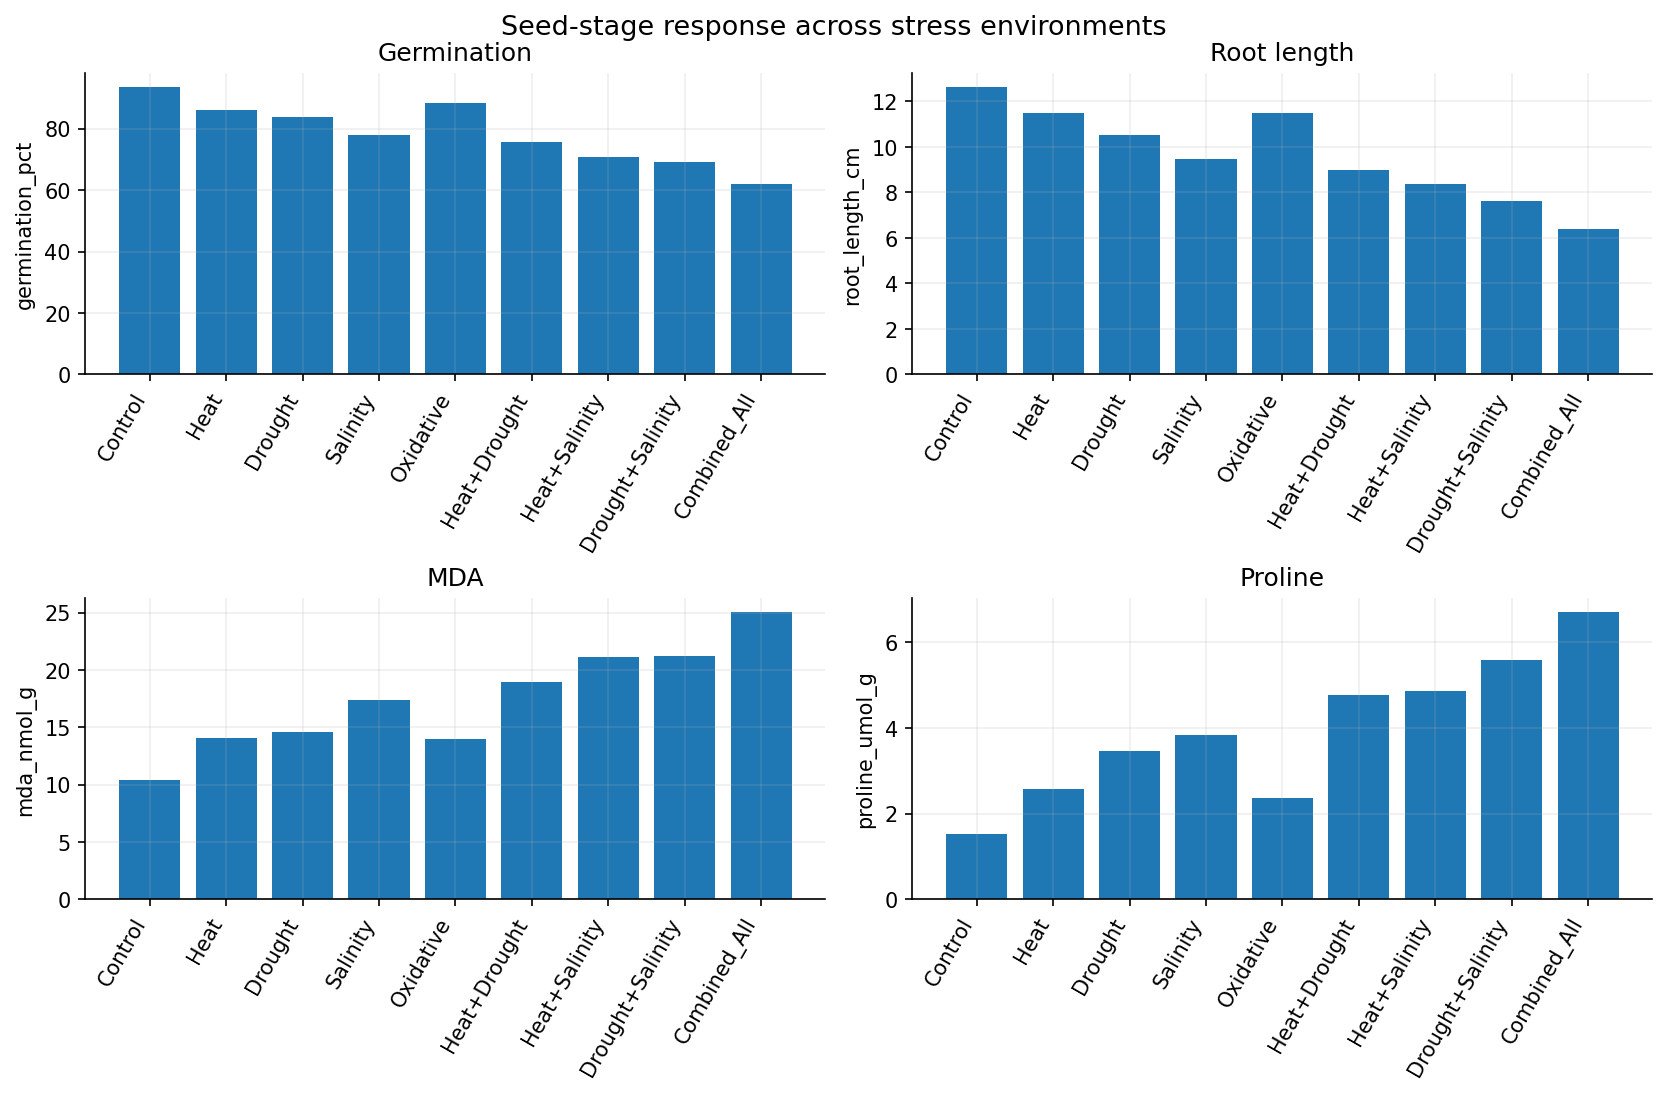

In [11]:

seed_plot = seed.groupby("treatment")[["germination_pct", "root_length_cm", "mda_nmol_g", "proline_umol_g"]].mean().loc[list(TREATMENTS.keys())]
fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)

for ax, col, title in zip(
    axes.flatten(),
    ["germination_pct", "root_length_cm", "mda_nmol_g", "proline_umol_g"],
    ["Germination", "Root length", "MDA", "Proline"]
):
    vals = seed_plot[col]
    ax.bar(range(len(vals)), vals.values)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=60, ha="right")
    ax.set_title(title)
    ax.set_ylabel(col)

fig.suptitle("Seed-stage response across stress environments", y=1.02, fontsize=13)
fig.savefig(FIGDIR / "figure_seed_stage_stress_profiles.png", bbox_inches="tight")
plt.show()


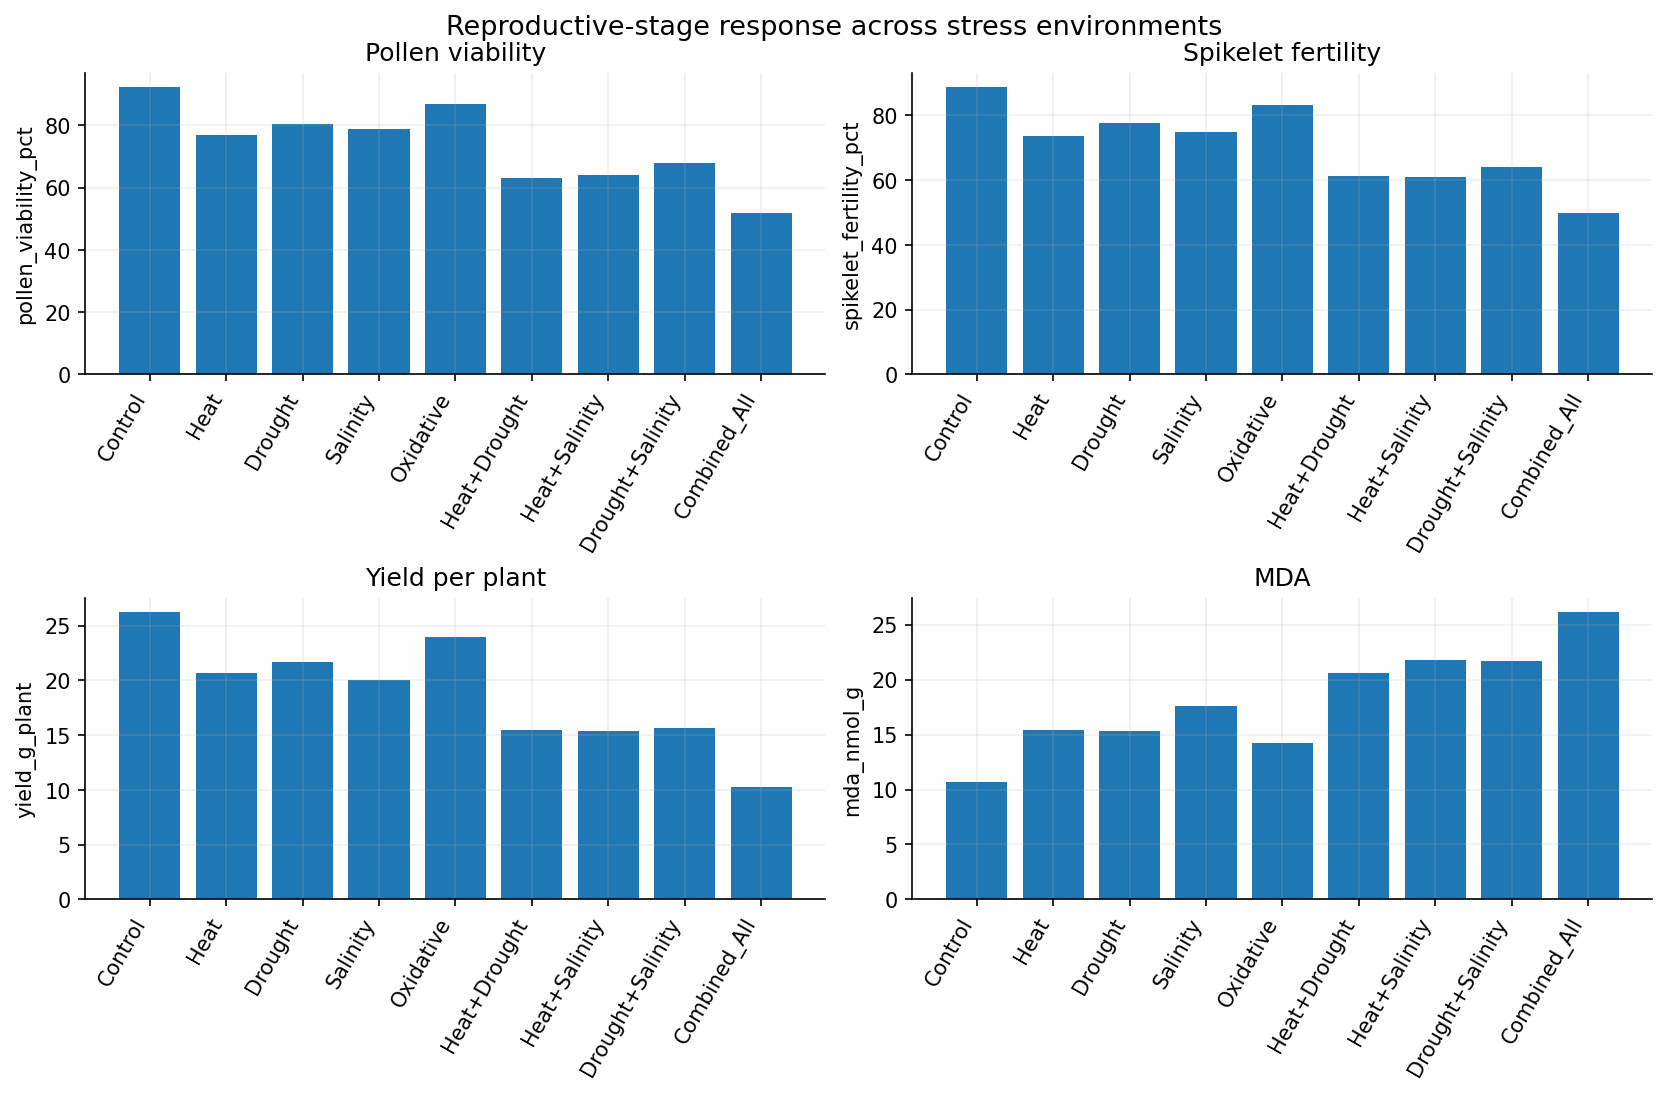

In [13]:

repro_plot = repro.groupby("treatment")[["pollen_viability_pct", "spikelet_fertility_pct", "yield_g_plant", "mda_nmol_g"]].mean().loc[list(TREATMENTS.keys())]
fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)

for ax, col, title in zip(
    axes.flatten(),
    ["pollen_viability_pct", "spikelet_fertility_pct", "yield_g_plant", "mda_nmol_g"],
    ["Pollen viability", "Spikelet fertility", "Yield per plant", "MDA"]
):
    vals = repro_plot[col]
    ax.bar(range(len(vals)), vals.values)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=60, ha="right")
    ax.set_title(title)
    ax.set_ylabel(col)

fig.suptitle("Reproductive-stage response across stress environments", y=1.02, fontsize=13)
fig.savefig(FIGDIR / "figure_reproductive_stage_stress_profiles.png", bbox_inches="tight")
plt.show()


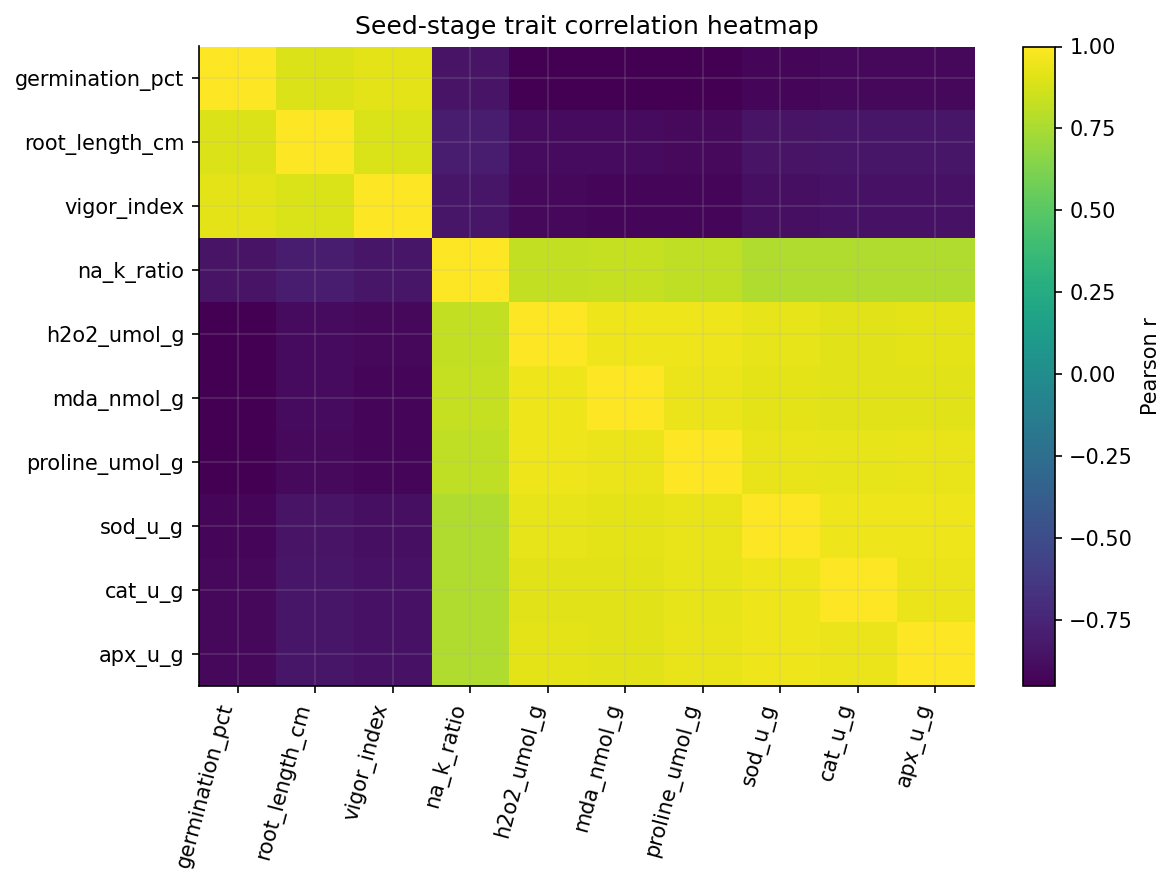

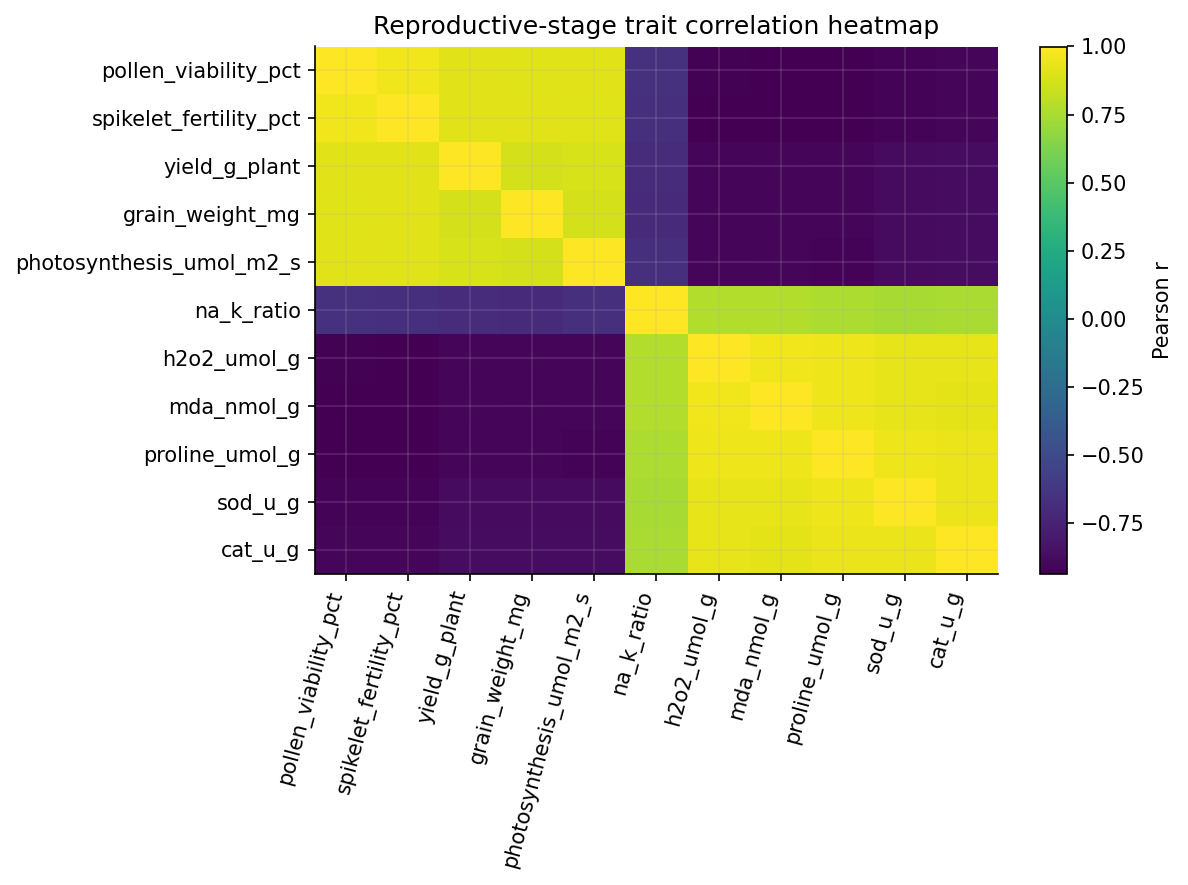

,germination_pct,root_length_cm,vigor_index,na_k_ratio,h2o2_umol_g,mda_nmol_g,proline_umol_g,sod_u_g,cat_u_g,apx_u_g
germination_pct,1.000,0.898,0.921,-0.852,-0.948,-0.945,-0.952,-0.922,-0.910,-0.913
root_length_cm,0.898,1.000,0.887,-0.807,-0.895,-0.892,-0.900,-0.852,-0.833,-0.837
vigor_index,0.921,0.887,1.000,-0.835,-0.914,-0.916,-0.921,-0.873,-0.859,-0.860
na_k_ratio,-0.852,-0.807,-0.835,1.000,0.820,0.830,0.814,0.771,0.765,0.764
h2o2_umol_g,-0.948,-0.895,-0.914,0.820,1.000,0.951,0.950,0.926,0.915,0.917


,pollen_viability_pct,spikelet_fertility_pct,yield_g_plant,grain_weight_mg,photosynthesis_umol_m2_s,na_k_ratio,h2o2_umol_g,mda_nmol_g,proline_umol_g,sod_u_g,cat_u_g
pollen_viability_pct,1.000,0.955,0.909,0.906,0.911,-0.658,-0.925,-0.934,-0.936,-0.918,-0.910
spikelet_fertility_pct,0.955,1.000,0.913,0.914,0.906,-0.679,-0.931,-0.938,-0.937,-0.919,-0.910
yield_g_plant,0.909,0.913,1.000,0.877,0.880,-0.693,-0.904,-0.909,-0.906,-0.881,-0.874
grain_weight_mg,0.906,0.914,0.877,1.000,0.875,-0.698,-0.904,-0.907,-0.901,-0.877,-0.870
photosynthesis_umol_m2_s,0.911,0.906,0.880,0.875,1.000,-0.676,-0.906,-0.908,-0.921,-0.883,-0.872


In [15]:

def corr_heatmap(df_in, cols, title, fname):
    corr = df_in[cols].corr()
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(corr.values, aspect="auto")
    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels(cols, rotation=75, ha="right")
    ax.set_yticks(range(len(cols)))
    ax.set_yticklabels(cols)
    ax.set_title(title)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Pearson r")
    fig.tight_layout()
    fig.savefig(FIGDIR / fname, bbox_inches="tight")
    plt.show()
    return corr.round(3)

seed_corr = corr_heatmap(
    seed,
    ["germination_pct", "root_length_cm", "vigor_index", "na_k_ratio", "h2o2_umol_g", "mda_nmol_g", "proline_umol_g", "sod_u_g", "cat_u_g", "apx_u_g"],
    "Seed-stage trait correlation heatmap",
    "figure_seed_trait_correlation_heatmap.png"
)
repro_corr = corr_heatmap(
    repro,
    ["pollen_viability_pct", "spikelet_fertility_pct", "yield_g_plant", "grain_weight_mg", "photosynthesis_umol_m2_s", "na_k_ratio", "h2o2_umol_g", "mda_nmol_g", "proline_umol_g", "sod_u_g", "cat_u_g"],
    "Reproductive-stage trait correlation heatmap",
    "figure_reproductive_trait_correlation_heatmap.png"
)

seed_corr.to_csv(TABDIR / "table_seed_trait_correlations.csv")
repro_corr.to_csv(TABDIR / "table_reproductive_trait_correlations.csv")
display(seed_corr.head())
display(repro_corr.head())


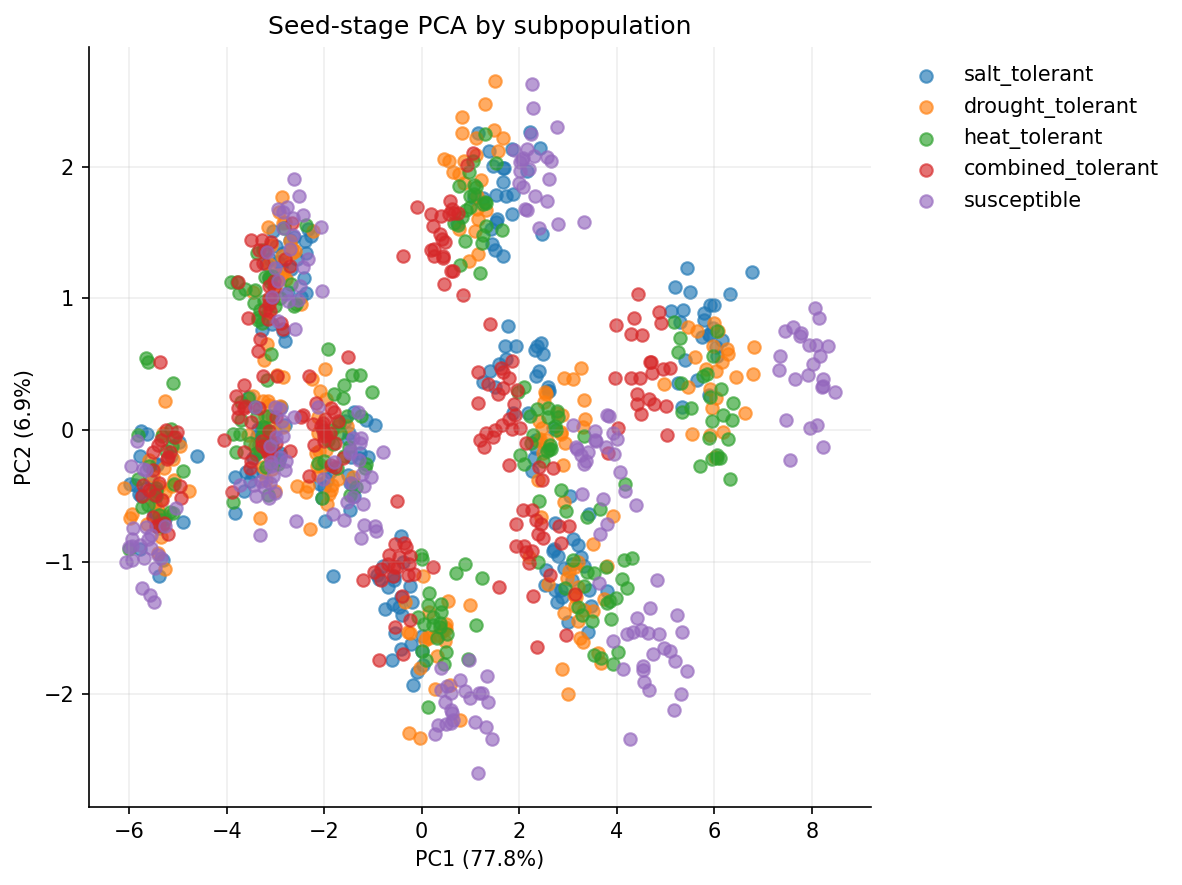

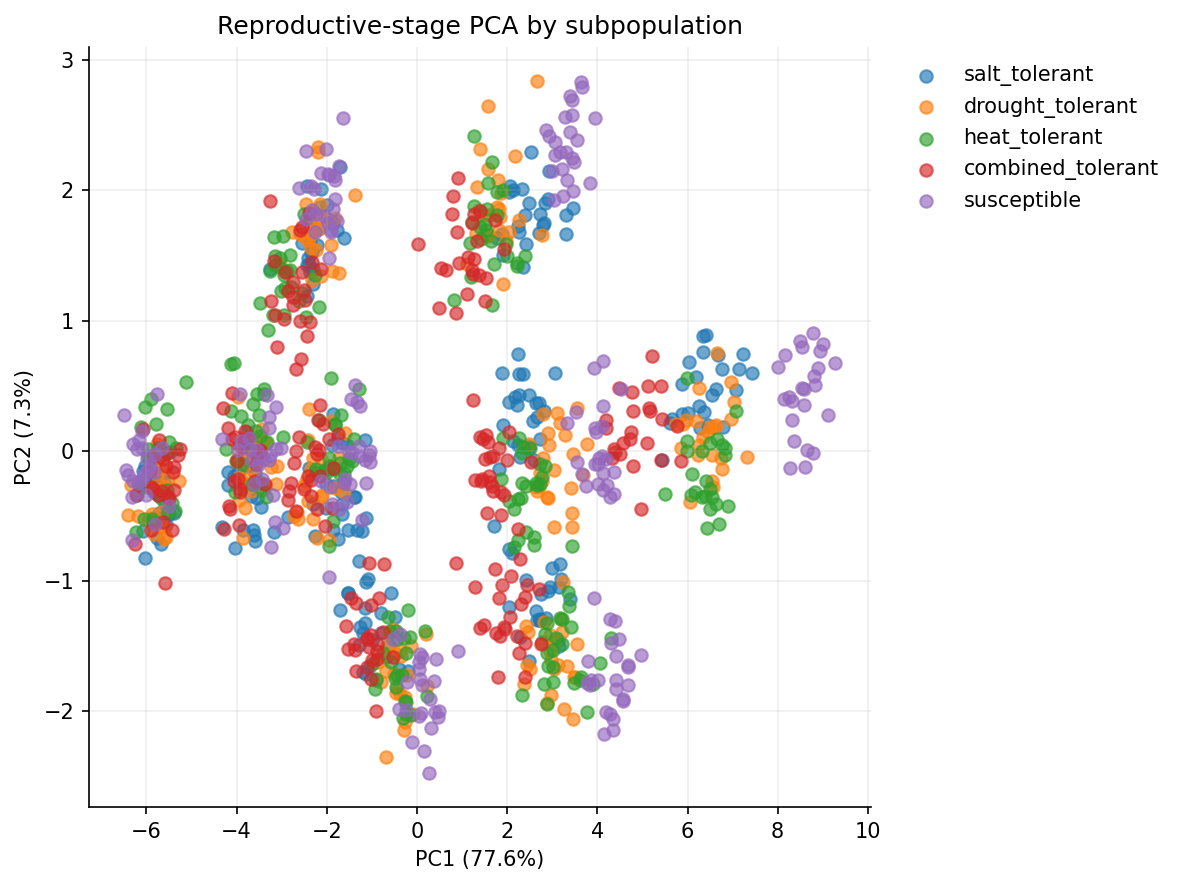

In [17]:

# PCA on seed-stage multi-trait space
seed_pca_cols = ["germination_pct", "root_length_cm", "vigor_index", "na_k_ratio", "h2o2_umol_g", "mda_nmol_g", "proline_umol_g", "sod_u_g", "cat_u_g", "apx_u_g", "rwc_pct", "OsHKT1_5_expr", "OsDREB2A_expr", "OsHSP101_expr", "OsAPX2_expr", "OsP5CS1_expr"]
seed_scaled = StandardScaler().fit_transform(seed[seed_pca_cols])
seed_pca = PCA(n_components=2)
seed_scores = seed_pca.fit_transform(seed_scaled)
seed_pca_df = seed[["genotype", "subpopulation", "treatment"]].copy()
seed_pca_df["PC1"] = seed_scores[:, 0]
seed_pca_df["PC2"] = seed_scores[:, 1]
seed_pca_df.to_csv(TABDIR / "table_seed_pca_scores.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 6))
for grp in seed_pca_df["subpopulation"].unique():
    tmp = seed_pca_df[seed_pca_df["subpopulation"] == grp]
    ax.scatter(tmp["PC1"], tmp["PC2"], label=grp, alpha=0.65)
ax.set_xlabel(f"PC1 ({seed_pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({seed_pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Seed-stage PCA by subpopulation")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGDIR / "figure_seed_stage_pca.png", bbox_inches="tight")
plt.show()

# PCA on reproductive-stage multi-trait space
repro_pca_cols = ["pollen_viability_pct", "spikelet_fertility_pct", "grain_weight_mg", "yield_g_plant", "photosynthesis_umol_m2_s", "na_k_ratio", "h2o2_umol_g", "mda_nmol_g", "proline_umol_g", "sod_u_g", "cat_u_g", "apx_u_g", "rwc_pct", "OsHKT1_5_expr", "OsDREB2A_expr", "OsHSP101_expr", "OsAPX2_expr", "OsP5CS1_expr"]
repro_scaled = StandardScaler().fit_transform(repro[repro_pca_cols])
repro_pca = PCA(n_components=2)
repro_scores = repro_pca.fit_transform(repro_scaled)
repro_pca_df = repro[["genotype", "subpopulation", "treatment"]].copy()
repro_pca_df["PC1"] = repro_scores[:, 0]
repro_pca_df["PC2"] = repro_scores[:, 1]
repro_pca_df.to_csv(TABDIR / "table_reproductive_pca_scores.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 6))
for grp in repro_pca_df["subpopulation"].unique():
    tmp = repro_pca_df[repro_pca_df["subpopulation"] == grp]
    ax.scatter(tmp["PC1"], tmp["PC2"], label=grp, alpha=0.65)
ax.set_xlabel(f"PC1 ({repro_pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({repro_pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Reproductive-stage PCA by subpopulation")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGDIR / "figure_reproductive_stage_pca.png", bbox_inches="tight")
plt.show()


In [19]:

# genotype-level aggregation and clustering
seed_genotype = seed.groupby(["genotype", "subpopulation"])[seed_pca_cols].mean().reset_index()
X_seed = StandardScaler().fit_transform(seed_genotype[seed_pca_cols])
seed_genotype["cluster"] = KMeans(n_clusters=4, random_state=42, n_init=20).fit_predict(X_seed)

repro_genotype = repro.groupby(["genotype", "subpopulation"])[repro_pca_cols].mean().reset_index()
X_repro = StandardScaler().fit_transform(repro_genotype[repro_pca_cols])
repro_genotype["cluster"] = KMeans(n_clusters=4, random_state=42, n_init=20).fit_predict(X_repro)

seed_genotype.to_csv(TABDIR / "table_seed_genotype_clusters.csv", index=False)
repro_genotype.to_csv(TABDIR / "table_reproductive_genotype_clusters.csv", index=False)

cluster_counts_seed = pd.crosstab(seed_genotype["subpopulation"], seed_genotype["cluster"])
cluster_counts_repro = pd.crosstab(repro_genotype["subpopulation"], repro_genotype["cluster"])

display(cluster_counts_seed)
display(cluster_counts_repro)


cluster,0,1,2,3
subpopulation,,,,
combined_tolerant,8,0,0,0
drought_tolerant,0,4,4,0
heat_tolerant,0,3,5,0
salt_tolerant,1,3,4,0
susceptible,0,0,0,8


cluster,0,1,2,3
subpopulation,,,,
combined_tolerant,8,0,0,0
drought_tolerant,0,0,4,4
heat_tolerant,1,0,3,4
salt_tolerant,0,0,5,3
susceptible,0,8,0,0


In [21]:

# Seed-stage linear models
seed_model = smf.ols("germination_pct ~ C(treatment) + general_resilience + C(treatment):general_resilience", data=seed).fit()
seed_anova = anova_lm(seed_model, typ=2).round(4)
seed_anova.to_csv(TABDIR / "table_seed_anova_germination.csv")

repro_model = smf.ols("spikelet_fertility_pct ~ C(treatment) + general_resilience + C(treatment):general_resilience", data=repro).fit()
repro_anova = anova_lm(repro_model, typ=2).round(4)
repro_anova.to_csv(TABDIR / "table_reproductive_anova_spikelet_fertility.csv")

display(seed_anova)
display(repro_anova)


,sum_sq,df,F,PR(>F)
C(treatment),100567.0711,8.0,2316.4319,0.0
general_resilience,4479.8425,1.0,825.4988,0.0
C(treatment):general_resilience,1012.4384,8.0,23.3202,0.0
Residual,5763.2944,1062.0,NaN,NaN


,sum_sq,df,F,PR(>F)
C(treatment),145966.1387,8.0,2498.7911,0.0
general_resilience,6077.1935,1.0,832.2827,0.0
C(treatment):general_resilience,2207.0669,8.0,37.7827,0.0
Residual,7754.5516,1062.0,NaN,NaN


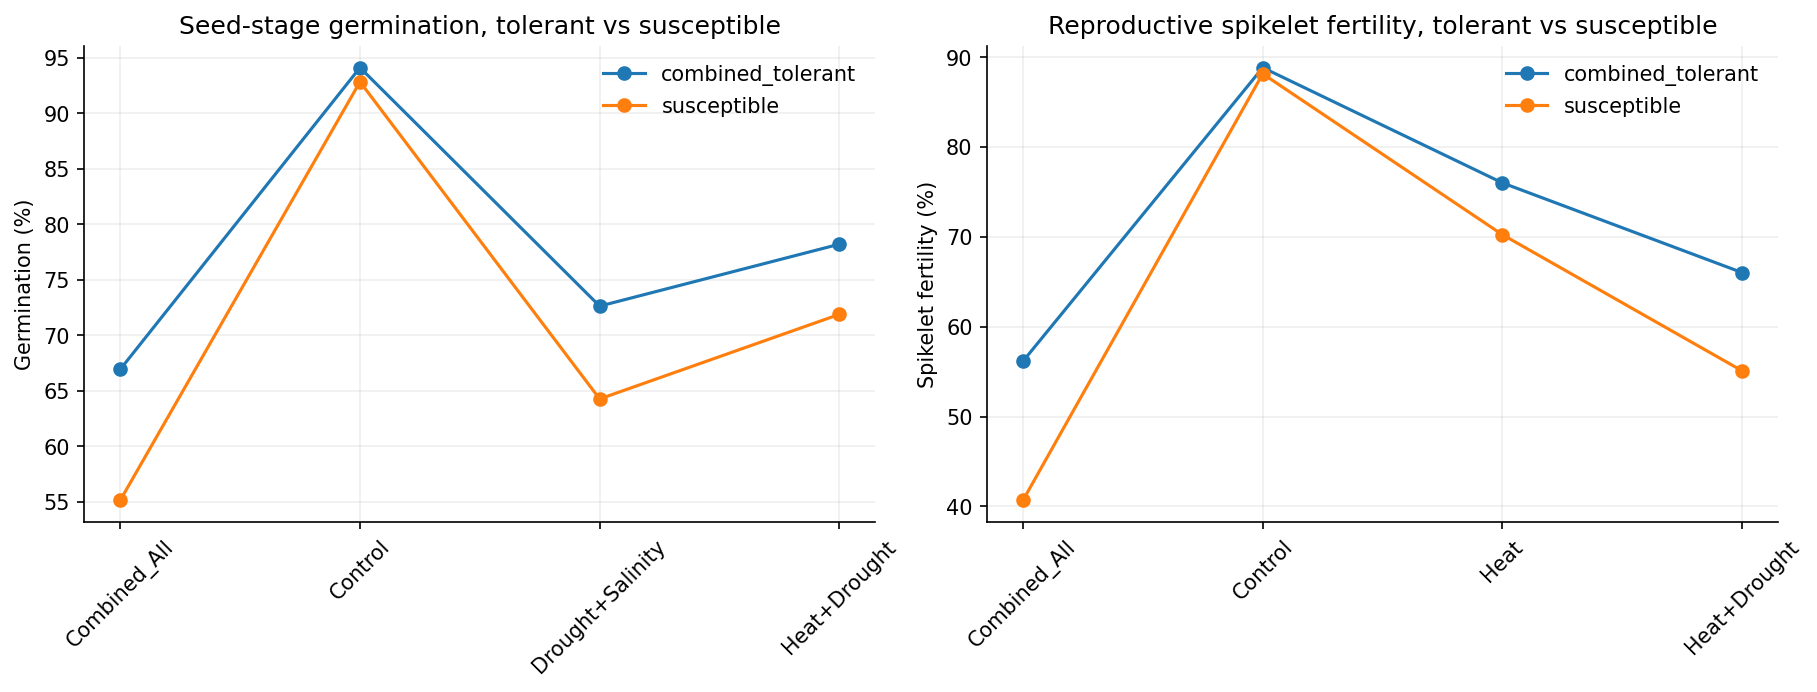

In [23]:

# Compare tolerant vs susceptible under combined stress
focus_seed = seed[seed["treatment"].isin(["Control", "Heat+Drought", "Drought+Salinity", "Combined_All"])].copy()
focus_repro = repro[repro["treatment"].isin(["Control", "Heat", "Heat+Drought", "Combined_All"])].copy()

seed_group = focus_seed.groupby(["subpopulation", "treatment"])[["germination_pct", "mda_nmol_g", "proline_umol_g"]].mean().reset_index()
repro_group = focus_repro.groupby(["subpopulation", "treatment"])[["spikelet_fertility_pct", "yield_g_plant", "mda_nmol_g"]].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for grp in ["combined_tolerant", "susceptible"]:
    tmp = seed_group[seed_group["subpopulation"] == grp]
    axes[0].plot(tmp["treatment"], tmp["germination_pct"], marker="o", label=grp)
axes[0].set_title("Seed-stage germination, tolerant vs susceptible")
axes[0].set_ylabel("Germination (%)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(frameon=False)

for grp in ["combined_tolerant", "susceptible"]:
    tmp = repro_group[repro_group["subpopulation"] == grp]
    axes[1].plot(tmp["treatment"], tmp["spikelet_fertility_pct"], marker="o", label=grp)
axes[1].set_title("Reproductive spikelet fertility, tolerant vs susceptible")
axes[1].set_ylabel("Spikelet fertility (%)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(frameon=False)

fig.savefig(FIGDIR / "figure_tolerant_vs_susceptible_profiles.png", bbox_inches="tight")
plt.show()


In [25]:

# ML regression for seed-stage germination
seed_features = [
    "subpopulation", "treatment", "general_resilience", "salt_score", "drought_score", "heat_score", "redox_score",
    "root_length_cm", "vigor_index", "na_k_ratio", "h2o2_umol_g", "mda_nmol_g", "proline_umol_g", "sod_u_g", "cat_u_g", "apx_u_g", "rwc_pct",
    "OsHKT1_5_expr", "OsDREB2A_expr", "OsHSP101_expr", "OsAPX2_expr", "OsP5CS1_expr"
]
X = seed[seed_features]
y = seed["germination_pct"]

cat_cols = ["subpopulation", "treatment"]
num_cols = [c for c in seed_features if c not in cat_cols]

pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols)
])

models = {
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "MLP": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=700, random_state=42)
}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

seed_reg_results = []
fitted_seed_models = {}

for name, model in models.items():
    pipe = Pipeline([("pre", pre), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    seed_reg_results.append({
        "model": name,
        "R2": r2_score(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
        "MAE": mean_absolute_error(y_test, pred)
    })
    fitted_seed_models[name] = pipe

seed_reg_results = pd.DataFrame(seed_reg_results).sort_values("R2", ascending=False).round(4)
seed_reg_results.to_csv(TABDIR / "table_seed_regression_model_performance.csv", index=False)
seed_reg_results


,model,R2,RMSE,MAE
0,RandomForest,0.9412,2.4040,1.9423
1,GradientBoosting,0.9335,2.5556,2.0430
2,MLP,0.9057,3.0443,2.4282


In [27]:

# ML regression for reproductive-stage yield
repro_features = [
    "subpopulation", "treatment", "general_resilience", "salt_score", "drought_score", "heat_score", "redox_score",
    "pollen_viability_pct", "spikelet_fertility_pct", "grain_weight_mg", "photosynthesis_umol_m2_s",
    "na_k_ratio", "h2o2_umol_g", "mda_nmol_g", "proline_umol_g", "sod_u_g", "cat_u_g", "apx_u_g", "rwc_pct",
    "OsHKT1_5_expr", "OsDREB2A_expr", "OsHSP101_expr", "OsAPX2_expr", "OsP5CS1_expr"
]
X = repro[repro_features]
y = repro["yield_g_plant"]

cat_cols = ["subpopulation", "treatment"]
num_cols = [c for c in repro_features if c not in cat_cols]

pre_repro = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols)
])

models = {
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "MLP": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=700, random_state=42)
}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

repro_reg_results = []
fitted_repro_models = {}

for name, model in models.items():
    pipe = Pipeline([("pre", pre_repro), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    repro_reg_results.append({
        "model": name,
        "R2": r2_score(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
        "MAE": mean_absolute_error(y_test, pred)
    })
    fitted_repro_models[name] = pipe

repro_reg_results = pd.DataFrame(repro_reg_results).sort_values("R2", ascending=False).round(4)
repro_reg_results.to_csv(TABDIR / "table_reproductive_regression_model_performance.csv", index=False)
repro_reg_results


,model,R2,RMSE,MAE
0,RandomForest,0.8633,1.8701,1.4609
1,GradientBoosting,0.8591,1.8983,1.4976
2,MLP,0.8491,1.9648,1.6071


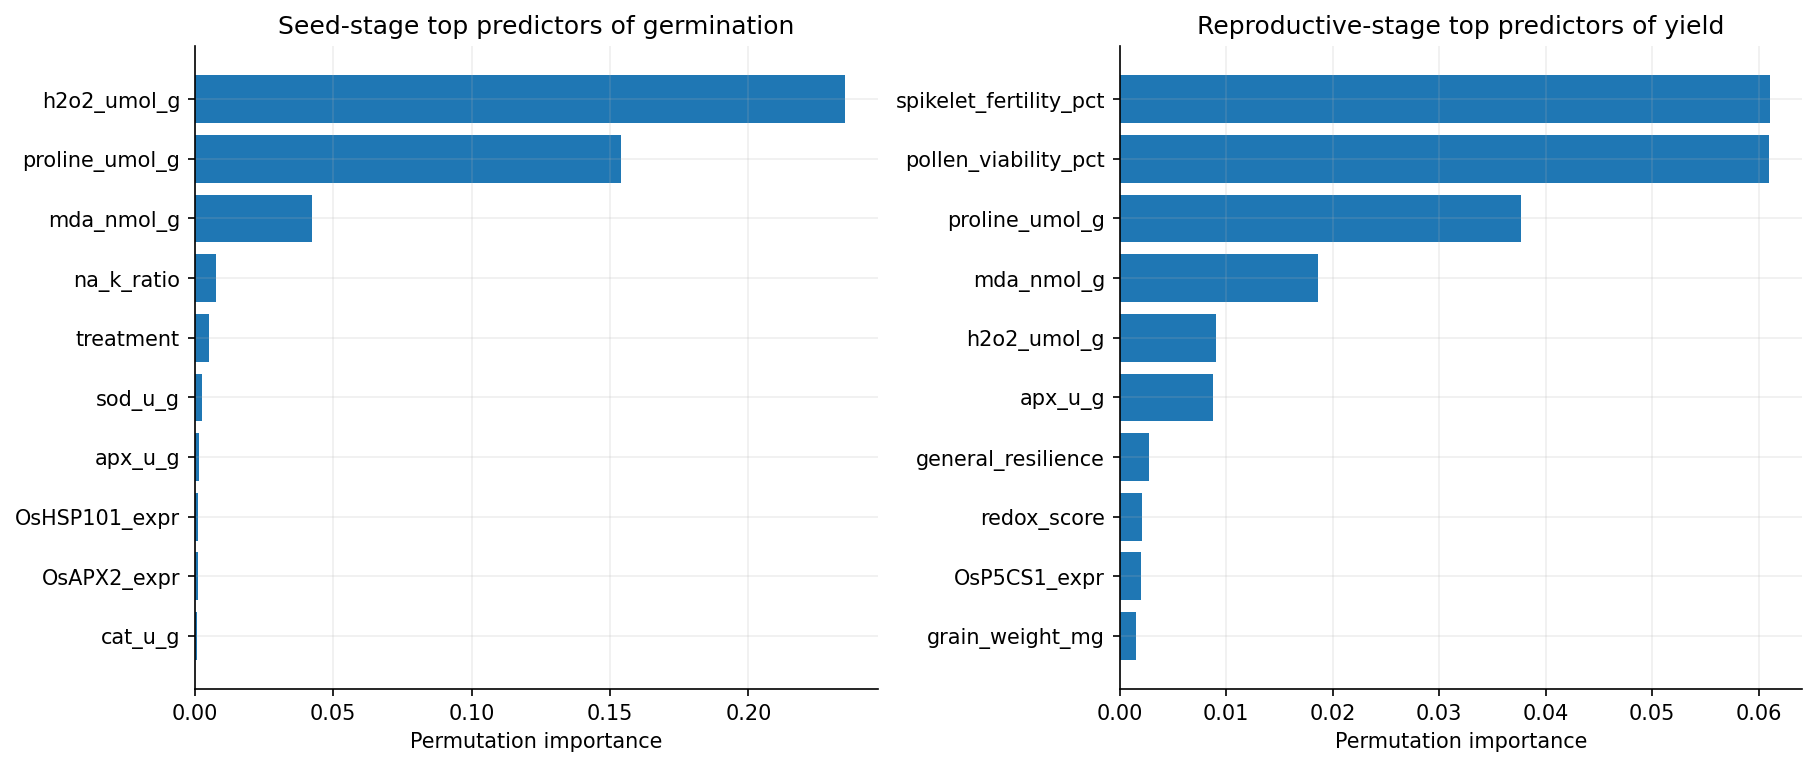

,feature,importance_mean,importance_std
10,h2o2_umol_g,0.234903,0.015877
12,proline_umol_g,0.154064,0.011339
11,mda_nmol_g,0.042264,0.004721
9,na_k_ratio,0.007584,0.001867
1,treatment,0.005099,0.001120
13,sod_u_g,0.002732,0.001113
15,apx_u_g,0.001623,0.000737
19,OsHSP101_expr,0.001214,0.000699
20,OsAPX2_expr,0.001058,0.000371
14,cat_u_g,0.000830,0.000475


,feature,importance_mean,importance_std
8,spikelet_fertility_pct,0.061069,0.005759
7,pollen_viability_pct,0.060971,0.004658
14,proline_umol_g,0.037650,0.004339
13,mda_nmol_g,0.018620,0.002946
12,h2o2_umol_g,0.009080,0.002667
17,apx_u_g,0.008738,0.002383
2,general_resilience,0.002741,0.001593
6,redox_score,0.002133,0.000820
23,OsP5CS1_expr,0.001993,0.000889
9,grain_weight_mg,0.001533,0.001181


In [29]:

# Interpretable feature importance using permutation importance on best RandomForest models

# Seed-stage
seed_X = seed[seed_features]
seed_y = seed["germination_pct"]
seed_X_train, seed_X_test, seed_y_train, seed_y_test = train_test_split(seed_X, seed_y, test_size=0.25, random_state=42)

best_seed_rf = Pipeline([
    ("pre", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["subpopulation", "treatment"]),
        ("num", StandardScaler(), [c for c in seed_features if c not in ["subpopulation", "treatment"]])
    ])),
    ("model", RandomForestRegressor(n_estimators=300, random_state=42))
])
best_seed_rf.fit(seed_X_train, seed_y_train)
seed_pi = permutation_importance(best_seed_rf, seed_X_test, seed_y_test, n_repeats=8, random_state=42)

seed_feature_names = list(seed_X.columns)
seed_importance = pd.DataFrame({
    "feature": seed_feature_names,
    "importance_mean": seed_pi.importances_mean[:len(seed_feature_names)],
    "importance_std": seed_pi.importances_std[:len(seed_feature_names)]
}).sort_values("importance_mean", ascending=False)

# Reproductive-stage
repro_X = repro[repro_features]
repro_y = repro["yield_g_plant"]
repro_X_train, repro_X_test, repro_y_train, repro_y_test = train_test_split(repro_X, repro_y, test_size=0.25, random_state=42)

best_repro_rf = Pipeline([
    ("pre", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["subpopulation", "treatment"]),
        ("num", StandardScaler(), [c for c in repro_features if c not in ["subpopulation", "treatment"]])
    ])),
    ("model", RandomForestRegressor(n_estimators=300, random_state=42))
])
best_repro_rf.fit(repro_X_train, repro_y_train)
repro_pi = permutation_importance(best_repro_rf, repro_X_test, repro_y_test, n_repeats=8, random_state=42)

repro_feature_names = list(repro_X.columns)
repro_importance = pd.DataFrame({
    "feature": repro_feature_names,
    "importance_mean": repro_pi.importances_mean[:len(repro_feature_names)],
    "importance_std": repro_pi.importances_std[:len(repro_feature_names)]
}).sort_values("importance_mean", ascending=False)

seed_importance.to_csv(TABDIR / "table_seed_feature_importance.csv", index=False)
repro_importance.to_csv(TABDIR / "table_reproductive_feature_importance.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
top_seed = seed_importance.head(10).iloc[::-1]
axes[0].barh(top_seed["feature"], top_seed["importance_mean"])
axes[0].set_title("Seed-stage top predictors of germination")
axes[0].set_xlabel("Permutation importance")

top_repro = repro_importance.head(10).iloc[::-1]
axes[1].barh(top_repro["feature"], top_repro["importance_mean"])
axes[1].set_title("Reproductive-stage top predictors of yield")
axes[1].set_xlabel("Permutation importance")

fig.savefig(FIGDIR / "figure_feature_importance_rf.png", bbox_inches="tight")
plt.show()

display(seed_importance.head(10))
display(repro_importance.head(10))


In [31]:

# Build breeder-friendly composite resilience indices
seed_index = seed.groupby("genotype").agg(
    mean_germination=("germination_pct", "mean"),
    mean_root=("root_length_cm", "mean"),
    mean_mda=("mda_nmol_g", "mean"),
    mean_nak=("na_k_ratio", "mean"),
    mean_sod=("sod_u_g", "mean")
).reset_index()

for c in ["mean_germination", "mean_root", "mean_sod"]:
    seed_index[c + "_z"] = (seed_index[c] - seed_index[c].mean()) / seed_index[c].std()
for c in ["mean_mda", "mean_nak"]:
    seed_index[c + "_z"] = -1 * (seed_index[c] - seed_index[c].mean()) / seed_index[c].std()

seed_index["seed_resilience_index"] = seed_index[[c for c in seed_index.columns if c.endswith("_z")]].mean(axis=1)
seed_index = seed_index.merge(genotype_info[["genotype", "subpopulation"]], on="genotype")
seed_index = seed_index.sort_values("seed_resilience_index", ascending=False)

repro_index = repro.groupby("genotype").agg(
    mean_spikelet=("spikelet_fertility_pct", "mean"),
    mean_yield=("yield_g_plant", "mean"),
    mean_photo=("photosynthesis_umol_m2_s", "mean"),
    mean_mda=("mda_nmol_g", "mean"),
    mean_nak=("na_k_ratio", "mean")
).reset_index()

for c in ["mean_spikelet", "mean_yield", "mean_photo"]:
    repro_index[c + "_z"] = (repro_index[c] - repro_index[c].mean()) / repro_index[c].std()
for c in ["mean_mda", "mean_nak"]:
    repro_index[c + "_z"] = -1 * (repro_index[c] - repro_index[c].mean()) / repro_index[c].std()

repro_index["reproductive_resilience_index"] = repro_index[[c for c in repro_index.columns if c.endswith("_z")]].mean(axis=1)
repro_index = repro_index.merge(genotype_info[["genotype", "subpopulation"]], on="genotype")
repro_index = repro_index.sort_values("reproductive_resilience_index", ascending=False)

breeder_ranking = seed_index[["genotype", "subpopulation", "seed_resilience_index"]].merge(
    repro_index[["genotype", "reproductive_resilience_index"]], on="genotype"
)
breeder_ranking["combined_breeding_priority"] = breeder_ranking[["seed_resilience_index", "reproductive_resilience_index"]].mean(axis=1)
breeder_ranking = breeder_ranking.sort_values("combined_breeding_priority", ascending=False)

seed_index.to_csv(TABDIR / "table_seed_resilience_index.csv", index=False)
repro_index.to_csv(TABDIR / "table_reproductive_resilience_index.csv", index=False)
breeder_ranking.to_csv(TABDIR / "table_breeder_priority_ranking.csv", index=False)

display(breeder_ranking.head(15))


,genotype,subpopulation,seed_resilience_index,reproductive_resilience_index,combined_breeding_priority
3,G29,combined_tolerant,0.852116,1.560777,1.206447
0,G25,combined_tolerant,0.964270,1.355983,1.160126
7,G32,combined_tolerant,0.752724,1.328259,1.040491
6,G27,combined_tolerant,0.761087,1.245423,1.003255
2,G30,combined_tolerant,0.897712,1.030177,0.963945
4,G28,combined_tolerant,0.814454,0.992621,0.903537
10,G31,combined_tolerant,0.636608,1.058685,0.847647
1,G01,salt_tolerant,0.904478,0.720776,0.812627
8,G17,heat_tolerant,0.677725,0.711727,0.694726
5,G08,salt_tolerant,0.784454,0.456704,0.620579


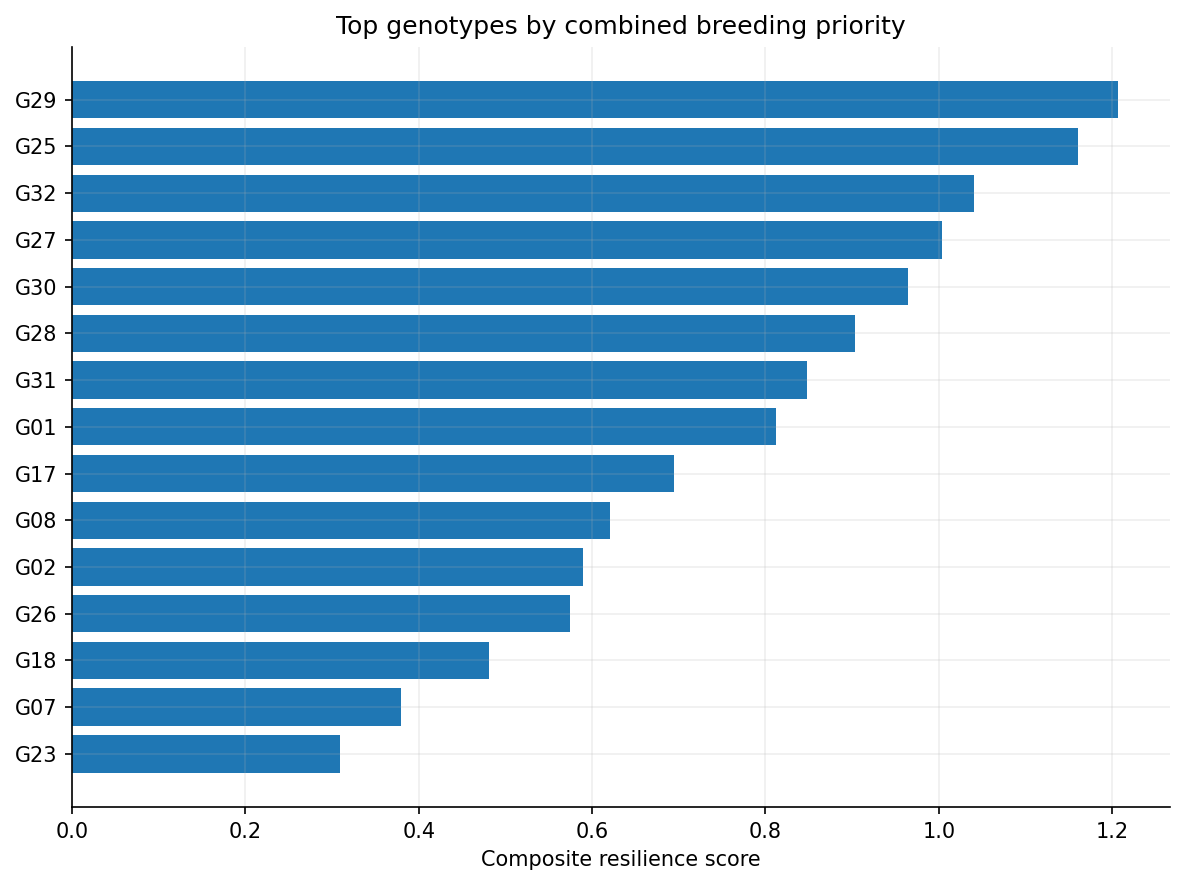

In [33]:

fig, ax = plt.subplots(figsize=(8, 6))
top = breeder_ranking.head(15).iloc[::-1]
ax.barh(top["genotype"], top["combined_breeding_priority"])
ax.set_title("Top genotypes by combined breeding priority")
ax.set_xlabel("Composite resilience score")
fig.tight_layout()
fig.savefig(FIGDIR / "figure_top_genotype_ranking.png", bbox_inches="tight")
plt.show()


In [35]:

# Export concise manuscript-ready tables
table_candidates = {
    "table_top15_breeding_priority.csv": breeder_ranking.head(15),
    "table_seed_stage_mean_by_treatment.csv": seed.groupby("treatment")[["germination_pct", "root_length_cm", "mda_nmol_g", "proline_umol_g", "sod_u_g", "na_k_ratio"]].mean().round(2),
    "table_reproductive_stage_mean_by_treatment.csv": repro.groupby("treatment")[["pollen_viability_pct", "spikelet_fertility_pct", "yield_g_plant", "grain_weight_mg", "mda_nmol_g", "proline_umol_g"]].mean().round(2),
}
for fname, table in table_candidates.items():
    table.to_csv(TABDIR / fname)

# Catalog outputs
catalog = []
for p in sorted(FIGDIR.glob("*.png")):
    catalog.append({"type": "figure", "path": str(p)})
for p in sorted(TABDIR.glob("*.csv")):
    catalog.append({"type": "table/data", "path": str(p)})
catalog_df = pd.DataFrame(catalog)
catalog_df.to_csv(OUTDIR / "output_catalog.csv", index=False)

print("Notebook run complete.")
print(f"Figures saved: {sum(catalog_df['type'] == 'figure')}")
print(f"Tables/data saved: {sum(catalog_df['type'] == 'table/data')}")
display(catalog_df.head(20))


Notebook run complete.
Figures saved: 9
Tables/data saved: 24


,type,path
0,figure,rice_resilience_outputs/figures/figure_feature...
1,figure,rice_resilience_outputs/figures/figure_reprodu...
2,figure,rice_resilience_outputs/figures/figure_reprodu...
3,figure,rice_resilience_outputs/figures/figure_reprodu...
4,figure,rice_resilience_outputs/figures/figure_seed_st...
5,figure,rice_resilience_outputs/figures/figure_seed_st...
6,figure,rice_resilience_outputs/figures/figure_seed_tr...
7,figure,rice_resilience_outputs/figures/figure_toleran...
8,figure,rice_resilience_outputs/figures/figure_top_gen...
9,table/data,rice_resilience_outputs/tables/dataset_overvie...
